# Following *The Tethered Viewer* Through Every CNN Layer

**COGSCI 139 — Art, Geometry, and Cognition · Second Delivery**

## TL;DR

This notebook passes my selected work, *The Tethered Viewer*, through the trained convolutional autoencoder once and records the output of **all 12 leaf layers**: three encoder convolutions, three encoder activations, three decoder transposed convolutions, two decoder ReLUs, and the final Sigmoid. The early layers retain edges and room divisions; the `32 × 16 × 16` bottleneck compresses them into coarse spatial regions; the decoder expands those regions but cannot restore handwriting or personal meaning.

## Context and method

The instructor asked us to examine the output of all layers as a figure is processed by a neural network. Forward hooks are attached to every leaf module. Each hook saves that module's real numerical output during one inference pass. The visualizations below show channel means normalized within each panel, so color indicates relative response inside a layer—not semantic attention and not directly comparable absolute strength across layers.

### Key assumptions

- The checkpoint was trained for 18 epochs on 800 programmatically generated geometric images.
- The network never trained on my artwork or on *Las Meninas*.
- The image is reduced to `128 × 128` before entering the network.

## Setup

The notebook uses the same compact model and trained checkpoint as the project experiment. It does not require `torchvision`; only PyTorch, Pillow, NumPy, and Matplotlib are used.

In [1]:
%matplotlib inline

import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageOps
from torch import nn

SEED = 139
IMAGE_SIZE = 128
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python/PyTorch environment ready: torch {torch.__version__}")
print(f"Fixed random seed: {SEED}")

Python/PyTorch environment ready: torch 2.11.0
Fixed random seed: 139


### Load the two submission assets

The notebook reads a small 128 × 128 copy of my artwork and the trained checkpoint from the neighboring `assets/` folder. Keeping binary data outside the notebook makes the Python code readable.

In [2]:
def findAsset(fileName: str) -> Path:
    searchRoots = [
        Path.cwd(),
        Path.cwd() / "submission",
        Path.cwd() / "OH_Programming" / "submission",
    ]
    for searchRoot in searchRoots:
        candidatePath = searchRoot / "assets" / fileName
        if candidatePath.is_file():
            return candidatePath.resolve()
    raise FileNotFoundError(
        f"Could not locate assets/{fileName}. Keep the assets folder beside the notebooks."
    )


artworkPath = findAsset("my-own-work-128.png")
checkpointPath = findAsset("geometric-autoencoder.pt")
print(f"Artwork:   {artworkPath.name}")
print(f"Checkpoint: {checkpointPath.name}")

Artwork:   my-own-work-128.png
Checkpoint: geometric-autoencoder.pt


### Model definition

The encoder lowers spatial resolution three times: `128 → 64 → 32 → 16`. The decoder then returns to `128 × 128`. There is no classifier, semantic label, attention mechanism, or skip connection.

In [3]:
class GeometricAutoencoder(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 12, kernel_size=5, stride=2, padding=2),
            nn.ReLU(inplace=False),
            nn.Conv2d(12, 24, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(24, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=False),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 24, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(24, 12, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(12, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, inputTensor: torch.Tensor) -> torch.Tensor:
        encodedTensor = self.encoder(inputTensor)
        return self.decoder(encodedTensor)


try:
    checkpoint = torch.load(checkpointPath, map_location="cpu", weights_only=False)
except TypeError:
    checkpoint = torch.load(checkpointPath, map_location="cpu")

model = GeometricAutoencoder()
model.load_state_dict(checkpoint["modelState"])
model.eval()

parameterCount = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"Trainable parameters: {parameterCount:,}")
print(f"Training configuration: {checkpoint['config']}")

GeometricAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 12, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(12, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(24, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 24, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(24, 12, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(12, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)
Trainable parameters: 27,983
Training configuration: {'imageSize': 128, 'trainSamples': 800, 'epochs': 18, 'batchSize': 32, 'learningRate': 0.001, 'seed': 139}


In [4]:
with Image.open(artworkPath) as sourceImage:
    artworkImage = ImageOps.exif_transpose(sourceImage).convert("RGB")

artworkArray = np.asarray(artworkImage, dtype=np.float32) / 255.0
inputTensor = torch.from_numpy(artworkArray).permute(2, 0, 1).unsqueeze(0)

print(f"Input image size: {artworkImage.size}")
print(f"Input tensor shape (NCHW): {tuple(inputTensor.shape)}")
print(f"Input range: {inputTensor.min().item():.4f} to {inputTensor.max().item():.4f}")

Input image size: (128, 128)
Input tensor shape (NCHW): (1, 3, 128, 128)
Input range: 0.4314 to 1.0000


## Results: capture every layer

Hooks are attached to the 12 modules that actually perform operations. The order below is the true forward-pass order.

In [5]:
layerOutputs = {}
hookHandles = []


def makeHook(layerName: str):
    def captureOutput(_module, _inputs, moduleOutput):
        layerOutputs[layerName] = moduleOutput.detach().cpu().clone()
    return captureOutput


leafLayers = [
    (layerName, layerModule)
    for layerName, layerModule in model.named_modules()
    if layerName and not list(layerModule.children())
]

for layerName, layerModule in leafLayers:
    hookHandles.append(layerModule.register_forward_hook(makeHook(layerName)))

with torch.inference_mode():
    reconstructionTensor = model(inputTensor)

for hookHandle in hookHandles:
    hookHandle.remove()

print(f"Forward pass completed: captured {len(layerOutputs)} of {len(leafLayers)} leaf layers.")
print(f"Final output shape: {tuple(reconstructionTensor.shape)}")

Forward pass completed: captured 12 of 12 leaf layers.
Final output shape: (1, 3, 128, 128)


### Numerical summary

The table makes the compression path explicit. Negative minima occur before ReLU; the following ReLU clips those values to zero. The final Sigmoid restricts reconstructed RGB values to `[0, 1]`.

In [6]:
header = f"{'#':>2}  {'layer':<12} {'type':<16} {'output shape':<22} {'min':>9} {'max':>9} {'mean':>9} {'std':>9}"
print(header)
print("-" * len(header))

for layerIndex, (layerName, layerModule) in enumerate(leafLayers, start=1):
    outputTensor = layerOutputs[layerName]
    print(
        f"{layerIndex:>2}  {layerName:<12} {type(layerModule).__name__:<16} "
        f"{str(tuple(outputTensor.shape)):<22} "
        f"{outputTensor.min().item():>9.4f} {outputTensor.max().item():>9.4f} "
        f"{outputTensor.mean().item():>9.4f} {outputTensor.std().item():>9.4f}"
    )

 #  layer        type             output shape                 min       max      mean       std
------------------------------------------------------------------------------------------------
 1  encoder.0    Conv2d           (1, 12, 64, 64)          -0.4468    3.6533    1.2224    1.0517
 2  encoder.1    ReLU             (1, 12, 64, 64)           0.0000    3.6533    1.2267    1.0462
 3  encoder.2    Conv2d           (1, 24, 32, 32)          -2.4071    5.8828    1.5973    1.9350
 4  encoder.3    ReLU             (1, 24, 32, 32)           0.0000    5.8828    1.9265    1.3885
 5  encoder.4    Conv2d           (1, 32, 16, 16)          -1.8479   10.4153    4.3273    2.3391
 6  encoder.5    ReLU             (1, 32, 16, 16)           0.0000   10.4153    4.3419    2.3092
 7  decoder.0    ConvTranspose2d  (1, 24, 32, 32)         -26.1265    9.8311    0.3091    5.4333
 8  decoder.1    ReLU             (1, 24, 32, 32)           0.0000    9.8311    2.0023    2.4075
 9  decoder.2    ConvTranspose

### Visual summary of all 12 layer outputs

Every panel below comes from the same forward pass. For multichannel tensors, the panel is the mean across channels; the final three-channel Sigmoid output is displayed as RGB.

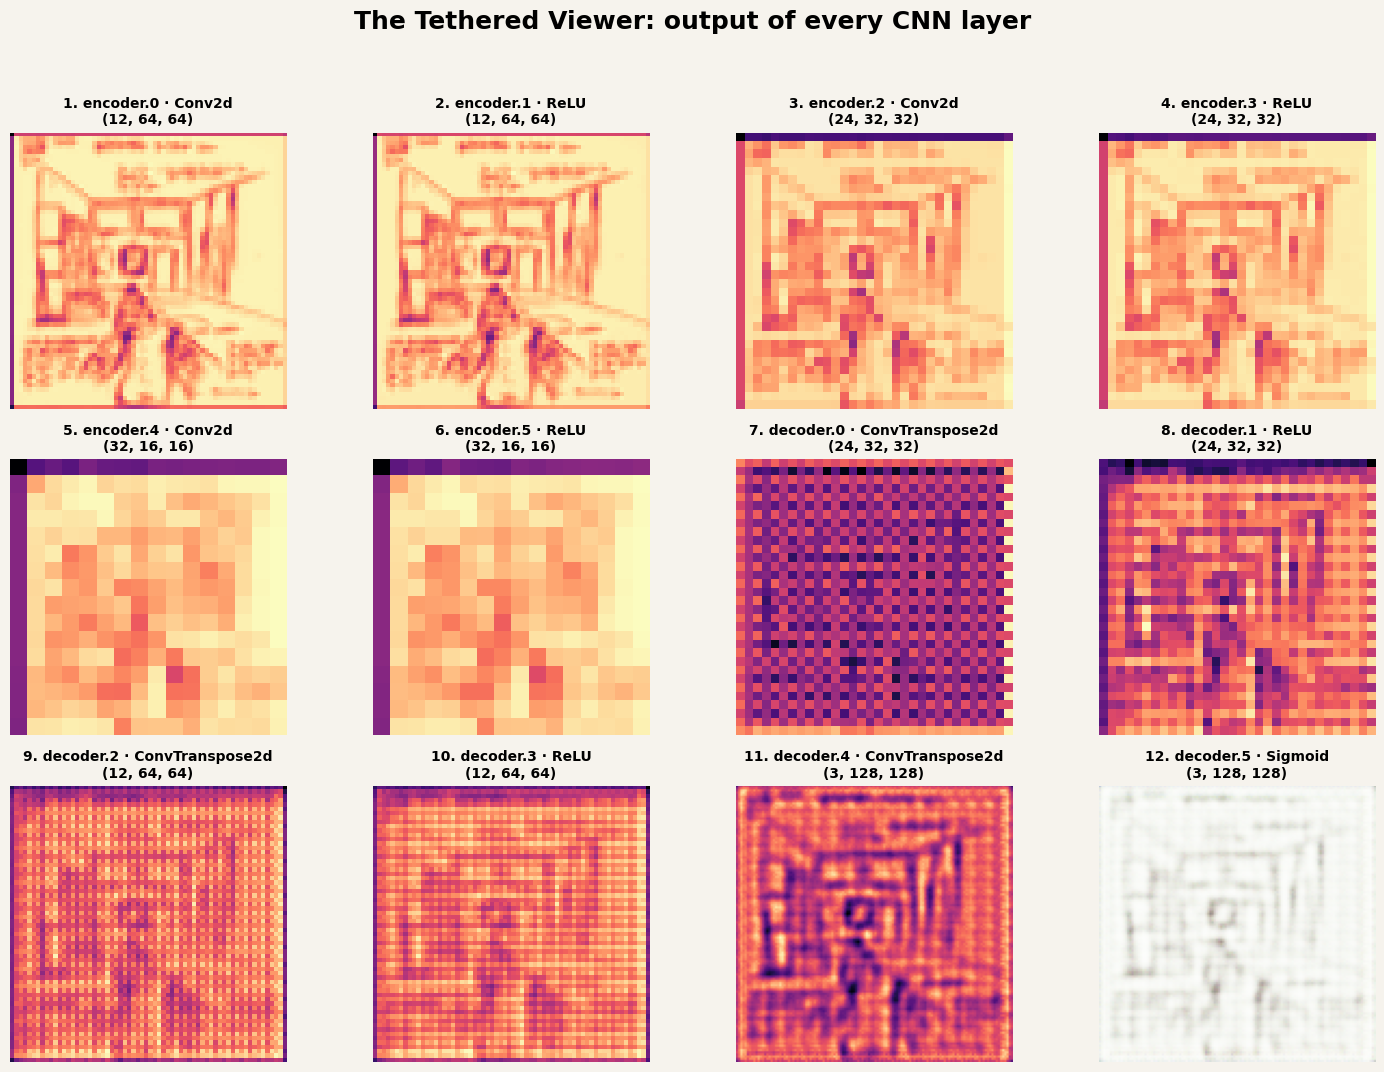

In [7]:
def normalizeMap(featureMap: np.ndarray) -> np.ndarray:
    minimumValue = float(featureMap.min())
    maximumValue = float(featureMap.max())
    if maximumValue - minimumValue < 1e-8:
        return np.zeros_like(featureMap)
    return (featureMap - minimumValue) / (maximumValue - minimumValue)


figure, axes = plt.subplots(3, 4, figsize=(15, 11), facecolor="#f6f3ed")
for layerIndex, (axis, (layerName, layerModule)) in enumerate(
    zip(axes.flat, leafLayers, strict=True), start=1
):
    outputTensor = layerOutputs[layerName][0]
    if layerName == "decoder.5":
        panelImage = outputTensor.permute(1, 2, 0).numpy()
        axis.imshow(np.clip(panelImage, 0.0, 1.0))
    else:
        channelMean = outputTensor.mean(dim=0).numpy()
        axis.imshow(normalizeMap(channelMean), cmap="magma", vmin=0.0, vmax=1.0)
    axis.set_title(
        f"{layerIndex}. {layerName} · {type(layerModule).__name__}\n{tuple(outputTensor.shape)}",
        fontsize=10,
        fontweight="bold",
    )
    axis.axis("off")

figure.suptitle(
    "The Tethered Viewer: output of every CNN layer",
    fontsize=18,
    fontweight="bold",
)
figure.tight_layout(rect=(0.01, 0.01, 0.99, 0.95))
plt.show()

### Individual channels in the first activated feature tensor

The mean maps above compress each tensor into one image. This second view shows that channels within a single layer respond differently to the same artwork. They separate local contrasts and directions without assigning natural-language meanings such as “mirror” or “person.”

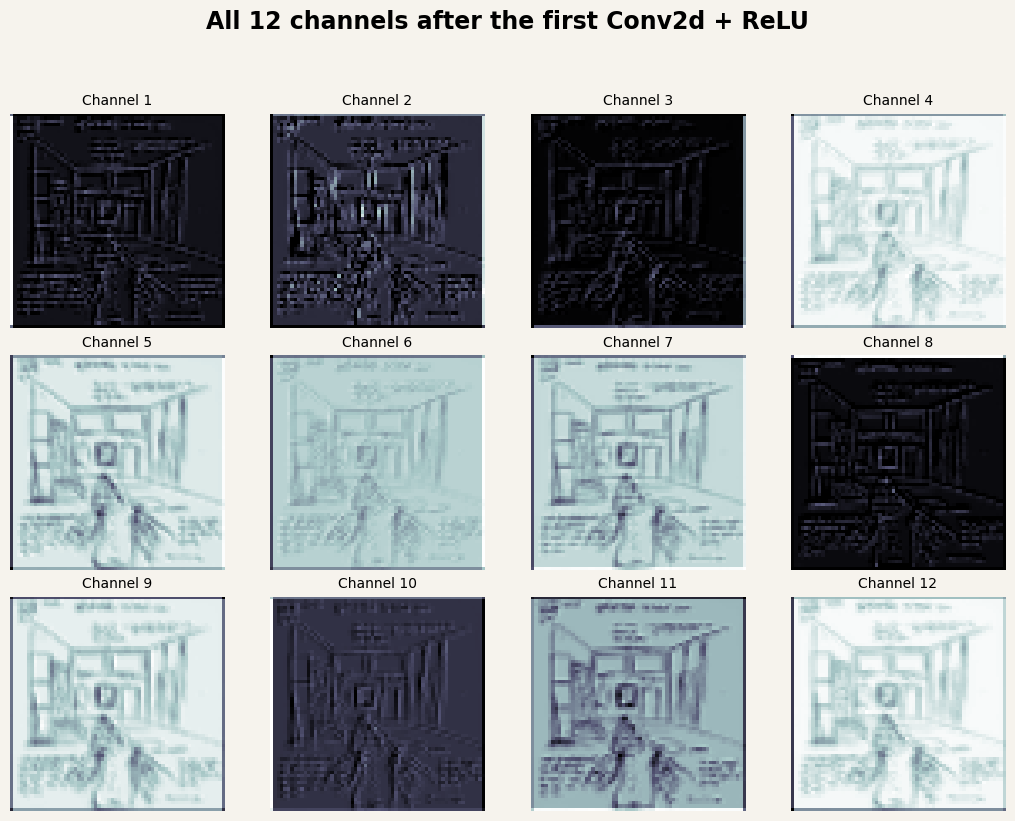

In [8]:
earlyTensor = layerOutputs["encoder.1"][0]
figure, axes = plt.subplots(3, 4, figsize=(11, 8.5), facecolor="#f6f3ed")
for channelIndex, axis in enumerate(axes.flat):
    channelMap = earlyTensor[channelIndex].numpy()
    axis.imshow(normalizeMap(channelMap), cmap="bone", vmin=0.0, vmax=1.0)
    axis.set_title(f"Channel {channelIndex + 1}", fontsize=10)
    axis.axis("off")

figure.suptitle(
    "All 12 channels after the first Conv2d + ReLU",
    fontsize=17,
    fontweight="bold",
)
figure.tight_layout(rect=(0.02, 0.02, 0.98, 0.94))
plt.show()

## Checks

The following assertions make the notebook fail visibly if a layer is missing, a tensor has an unexpected shape, or any output contains `NaN`/infinite values.

In [9]:
expectedLayerNames = [
    "encoder.0", "encoder.1", "encoder.2", "encoder.3", "encoder.4", "encoder.5",
    "decoder.0", "decoder.1", "decoder.2", "decoder.3", "decoder.4", "decoder.5",
]
expectedShapes = [
    (1, 12, 64, 64), (1, 12, 64, 64),
    (1, 24, 32, 32), (1, 24, 32, 32),
    (1, 32, 16, 16), (1, 32, 16, 16),
    (1, 24, 32, 32), (1, 24, 32, 32),
    (1, 12, 64, 64), (1, 12, 64, 64),
    (1, 3, 128, 128), (1, 3, 128, 128),
]

assert list(layerOutputs) == expectedLayerNames
assert [tuple(layerOutputs[name].shape) for name in expectedLayerNames] == expectedShapes
assert all(torch.isfinite(layerOutputs[name]).all() for name in expectedLayerNames)
assert tuple(reconstructionTensor.shape) == (1, 3, 128, 128)

print("PASS: all 12 layer outputs were captured in the correct order.")
print("PASS: every tensor has the expected shape and contains only finite values.")
print("PASS: final reconstruction returns to the input shape, 1 × 3 × 128 × 128.")

PASS: all 12 layer outputs were captured in the correct order.
PASS: every tensor has the expected shape and contains only finite values.
PASS: final reconstruction returns to the input shape, 1 × 3 × 128 × 128.


## Takeaways

1. The network progressively changes the image from RGB pixels into multiple feature channels while reducing spatial resolution.
2. ReLU is visible as an operation: negative convolution responses are removed before the next convolution.
3. At the bottleneck, the drawing is represented by `32 × 16 × 16` activations. The arrangement remains spatial, but fine writing and contours are no longer recoverable.
4. The decoder enlarges the compressed representation into a plausible geometric reconstruction. It does not retrieve meaning from a hidden label.
5. A CNN can separate visual regularities across channels, but the interpretation of those patterns remains a human act.